In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

Inits for the invariant distribution for a range of $N$, all for $M = 100$, for both quadratic and quartic potentials add more later...

In [ ]:
Ns = np.logspace(np.log10(30.5), np.log10(300.5), 8, dtype = int) # .5 for inclusive [30, 500]
print(f"For Ns", Ns)
all_snapshots = []
final_snapshots = []
accept_infos = []

beta = 2.0; M = 10; T = 2.0;
potential_name = "quadratic"

for j, N in enumerate(Ns):
    dt = 0.5/(N**(3/2)); total_steps = int(T/dt);
    print(f"({j+1} of {len(Ns)}) On N{N} for a total of {total_steps} steps.")

    init = random_matrix.init_gue_eigenvalues(M, N)
    pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)

    config = {"burn_in": int(0.5/dt), "snapshot_interval": 3, "track_accepts": True}
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)
    all_snapshots.append(info["snapshots"])
    final_snapshots.append(info["snapshots"][-1])
    accept_infos.append(info["accepts"])

    if (np.mean(info["accepts"]) < 0.3):
        raise ValueError("Acceptance rate too low.")

For Ns [ 30  41  56  77 105 144 196 268 366 500]
(1 of 10) On N30 for a total of 328 steps.
(2 of 10) On N41 for a total of 525 steps.
(3 of 10) On N56 for a total of 838 steps.
(4 of 10) On N77 for a total of 1351 steps.
(5 of 10) On N105 for a total of 2151 steps.
(6 of 10) On N144 for a total of 3456 steps.
(7 of 10) On N196 for a total of 5488 steps.
(8 of 10) On N268 for a total of 8774 steps.
(9 of 10) On N366 for a total of 14003 steps.
(10 of 10) On N500 for a total of 22360 steps.


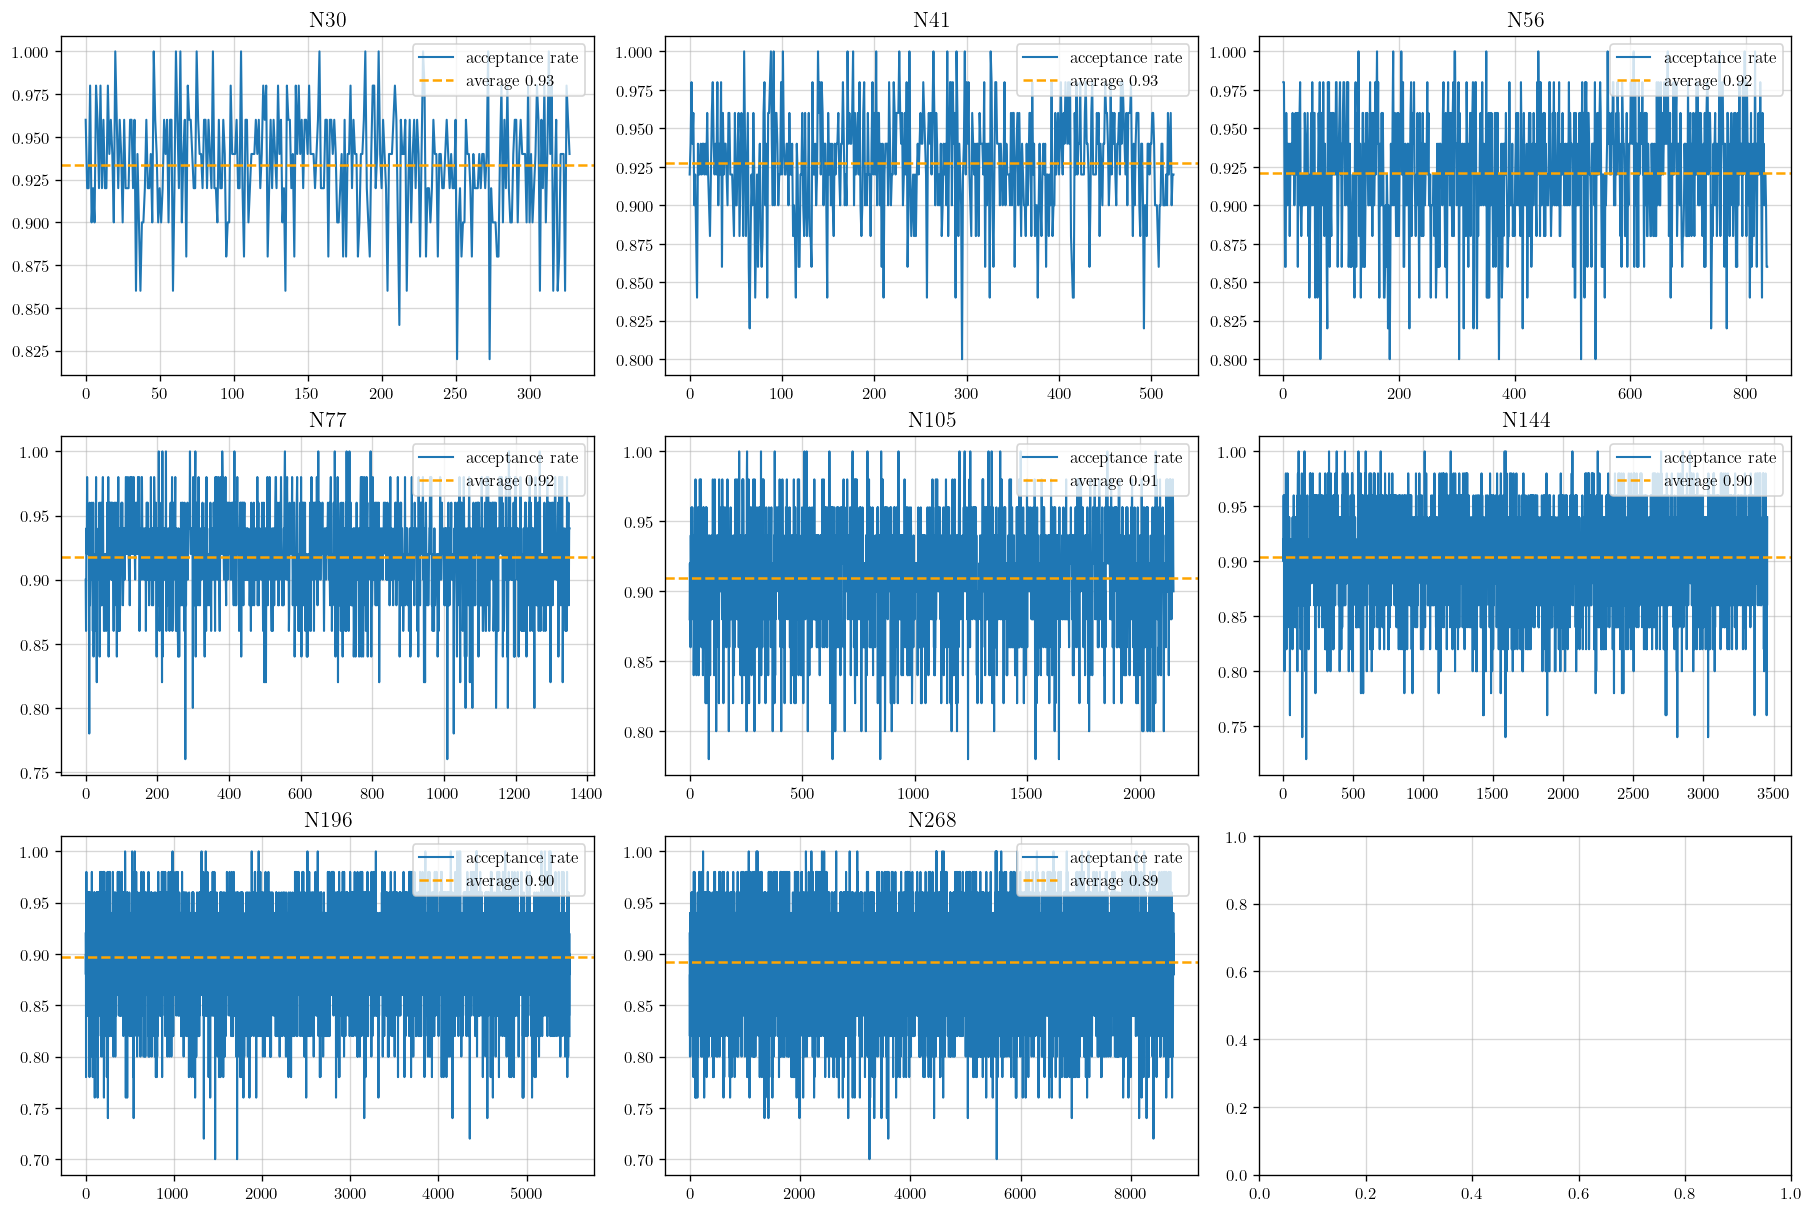

In [3]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes_flat = axes.flatten()

for j, ax in enumerate(axes_flat):    
    if (j >= 8):
        continue
    plotters.plot_accepts(ax, accept_infos[j])
    ax.set_title(f"N{Ns[j]}")

plt.show()

In [4]:
for j, N in enumerate(Ns):
    filename = f"data/inits/{potential_name}/M{M}-N{N}.pkl"
    N_init = np.array(final_snapshots[j])
    
    with open(filename, 'wb') as f:
        pickle.dump(N_init, f)